Train shape: (125973, 41)  Test shape: (22543, 41)


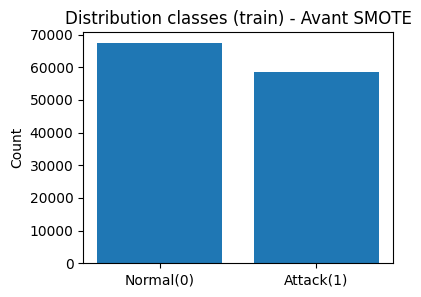


=== ML RandomForest (baseline) ===
Accuracy : 0.7790
Precision: 0.9693
Recall   : 0.6317
F1-score : 0.7649


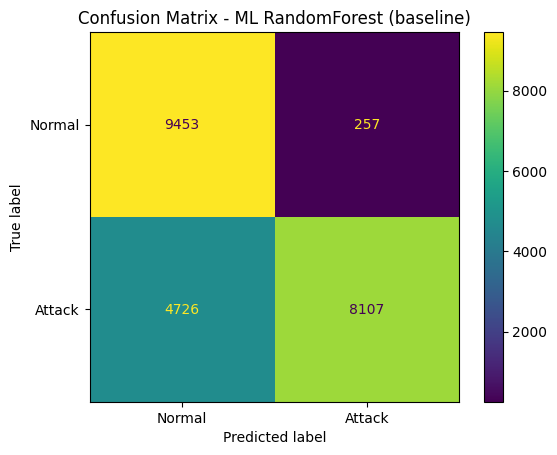

ROC-AUC  : 0.9618


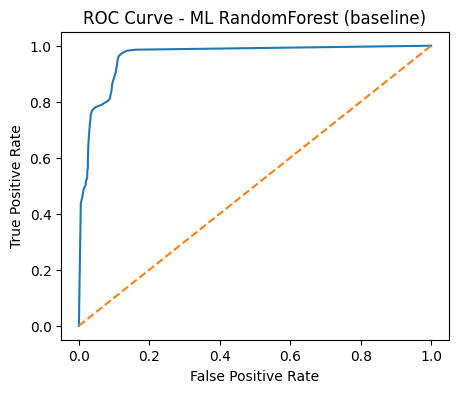

In [1]:
# ============================================================
# TP IDS rapide (NSL-KDD) : ML vs DL vs Hybride + SMOTE
# Google Colab - prêt à exécuter
# ============================================================

!pip -q install imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import tensorflow as tf
from tensorflow import keras

# ----------------------------
# 1) Télécharger le dataset
# ----------------------------
# Source GitHub (CSV prêts) - Repo: Jehuty4949/NSL_KDD
# (Si jamais ça échoue, tu peux changer vers un autre miroir)
train_url = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTrain%2B.csv"
test_url  = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTest%2B.csv"

train_path = "KDDTrain+.csv"
test_path  = "KDDTest+.csv"

!wget -q -O "{train_path}" "{train_url}"
!wget -q -O "{test_path}" "{test_url}"

# ----------------------------
# 2) Définir les colonnes NSL-KDD
# ----------------------------
# NSL-KDD : 41 features + label + (optionnel) difficulty
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv(train_path, header=None, names=col_names)
test_df  = pd.read_csv(test_path,  header=None, names=col_names)

# ----------------------------
# 3) Binariser le label : normal vs attack
# ----------------------------
def to_binary(y):
    return np.where(y == "normal", 0, 1)

y_train = to_binary(train_df["label"].values)
y_test  = to_binary(test_df["label"].values)

X_train_raw = train_df.drop(columns=["label","difficulty"])
X_test_raw  = test_df.drop(columns=["label","difficulty"])

print("Train shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)

# Visualiser imbalance
def show_class_distribution(y, title):
    values, counts = np.unique(y, return_counts=True)
    labels = ["Normal(0)", "Attack(1)"]
    plt.figure(figsize=(4,3))
    plt.bar([labels[v] for v in values], counts)
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

show_class_distribution(y_train, "Distribution classes (train) - Avant SMOTE")

# ----------------------------
# 4) Préprocessing : OneHot + Scaling
# ----------------------------
cat_cols = ["protocol_type","service","flag"]
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="drop"
)

# Utilitaire métriques + ROC + matrice de confusion
def evaluate_binary(model_name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Attack"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        print(f"ROC-AUC  : {auc:.4f}")
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1], linestyle="--")
        plt.title(f"ROC Curve - {model_name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.show()

# ============================================================
# TP 1) ML Baseline : RandomForest
# ============================================================
rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", rf)
])

rf_pipe.fit(X_train_raw, y_train)
rf_pred = rf_pipe.predict(X_test_raw)
rf_proba = rf_pipe.predict_proba(X_test_raw)[:,1]

evaluate_binary("ML RandomForest (baseline)", y_test, rf_pred, rf_proba)